In [10]:
# Import required modules
import sys
sys.path.append('../src')
from signalgen.signal_generator import SignalConfig, SignalGenerator
import matplotlib.pyplot as plt
import numpy as np
# Set up matplotlib for better plots - adjusted for screen fitting
plt.rcParams['figure.figsize'] = (10, 6)  # Reduced from (15, 10) for better screen fit
plt.rcParams['font.size'] = 10  # Slightly smaller font
plt.rcParams['figure.dpi'] = 100  # Standard DPI for better display
plt.rcParams['figure.max_open_warning'] = 20  # Allow more figures

# Enable interactive matplotlib backend for Jupyter notebooks
# %matplotlib widget

# Scenario 1: 1 main source
config_main_only = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=512,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[90],  # Angles for each source
    use_full_bandwidth=True
)

# Scenario 2: 1 main source + 1 interference
config_main_1_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[100, 100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[90, 40],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    use_full_bandwidth=True
)

# Scenario 3: 1 main source + 2 interference
config_main_2_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=3,  # Number of sources
    frequencies=[100, 200, 300],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[87, 90, 95],  # Angles for main signal and interferences
    sir_db=[0, 0],  # Signal-to-interference ratios
    use_full_bandwidth=True
)

# Scenario 4: 1 main source + 1 multipath
config_main_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[45],  # Angles for each source
    smr=[0],
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=False
)

# Scenario 5: 1 main source + 2 multipath
config_main_2_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True
)

# Scenario 6: 1 main source + 1 interference + 1 multipath
config_main_1_interference_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=512,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[100, 200],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[90, 70],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    smr=[0],
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True
)

# Initialize signal generators for all scenarios
generator_main_only = SignalGenerator(config_main_only)
generator_main_1_interference = SignalGenerator(config_main_1_interference)
generator_main_2_interference = SignalGenerator(config_main_2_interference)
generator_main_1_mp = SignalGenerator(config_main_1_mp)
generator_main_2_mp = SignalGenerator(config_main_2_mp)
generator_main_1_interference_1_mp = SignalGenerator(config_main_1_interference_1_mp)

# Generate time axis
t = generator_main_only.generate_time_axis()

# Generate source signals for all scenarios
signals_main_only = generator_main_only.generate_source_signals(t)
signals_main_1_interference = generator_main_1_interference.generate_source_signals(t)
signals_main_2_interference = generator_main_2_interference.generate_source_signals(t)

# Generate signals for multipath scenarios
signals_main_1_mp = generator_main_1_mp.generate_source_signals(t)
signals_main_2_mp = generator_main_2_mp.generate_source_signals(t)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.generate_source_signals(t)

# Add multipath effects to multipath scenarios
signals_main_1_mp, _ = generator_main_1_mp.add_multipath(signals_main_1_mp, t, config_main_1_mp.fs, 2.4e9, config_main_1_mp.bandwidth, num_multipath_components=1)
signals_main_2_mp, _ = generator_main_2_mp.add_multipath(signals_main_2_mp, t, config_main_2_mp.fs, 2.4e9, config_main_2_mp.bandwidth, num_multipath_components=2)
signals_main_1_interference_1_mp, _ = generator_main_1_interference_1_mp.add_multipath(signals_main_1_interference_1_mp, t, config_main_1_interference_1_mp.fs, 2.4e9, config_main_1_interference_1_mp.bandwidth, num_multipath_components=1)

signal = signals_main_1_interference
signal_config = config_main_1_interference

# Calculate power of each signal row
# signal_power_row0 = np.mean(np.abs(signal[0])**2)
# signal_power_row1 = np.mean(np.abs(signal[1])**2)

# print(f"Power of signal row 0: {signal_power_row0:.6f}")
# print(f"Power of signal row 1: {signal_power_row1:.6f}")

# Calculate correlation between the two rows
correlation = np.corrcoef(signal)[0, 1]
correlation_magnitude = np.abs(correlation)
correlation_phase = np.angle(correlation)

print(f"\nCorrelation between rows:")
print(f"Complex correlation: {correlation:.6f}")
print(f"Correlation magnitude: {correlation_magnitude:.6f}")
print(f"Correlation phase: {correlation_phase:.6f} radians ({np.degrees(correlation_phase):.2f} degrees)")



Correlation between rows:
Complex correlation: -0.005135+0.028977j
Correlation magnitude: 0.029429
Correlation phase: 1.746177 radians (100.05 degrees)


In [11]:
from signalgen.array_processing import ArrayConfig, ArrayModel

config = ArrayConfig(
    array_type='triangular',
    num_elements=4,
    carrier_freq=0.435e9,
    element_spacing=0.5,
    radius=0.5,
    enable_gain_phase_errors=True,
    enable_mutual_coupling=True,
    position_error_std=0,
    
)
config_cross = ArrayConfig(
    array_type='cross',
    num_elements=9,
    carrier_freq=0.435e9,
    element_spacing=1/3,
    radius=0.5
    
    # enable_gain_phase_errors=True,
    # enable_mutual_coupling=True,
    # position_error_std=0.001,
)

config_linear = ArrayConfig(
    array_type='linear',
    num_elements=8,
    carrier_freq=2.4e9,
    element_spacing=0.5,
    radius=0.5,
    position_error_std=0.001,
    enable_mutual_coupling=True,
    enable_gain_phase_errors=True,
)

array_model = ArrayModel(config_linear)
if array_model.config.array_type == 'linear':
    angles = np.linspace(0, 180, 180)
else:
    angles = np.linspace(0, 360, 360)
A = array_model.steering_matrix(angles, nominal=False)
A_nominal = array_model.steering_matrix(angles, nominal=True)



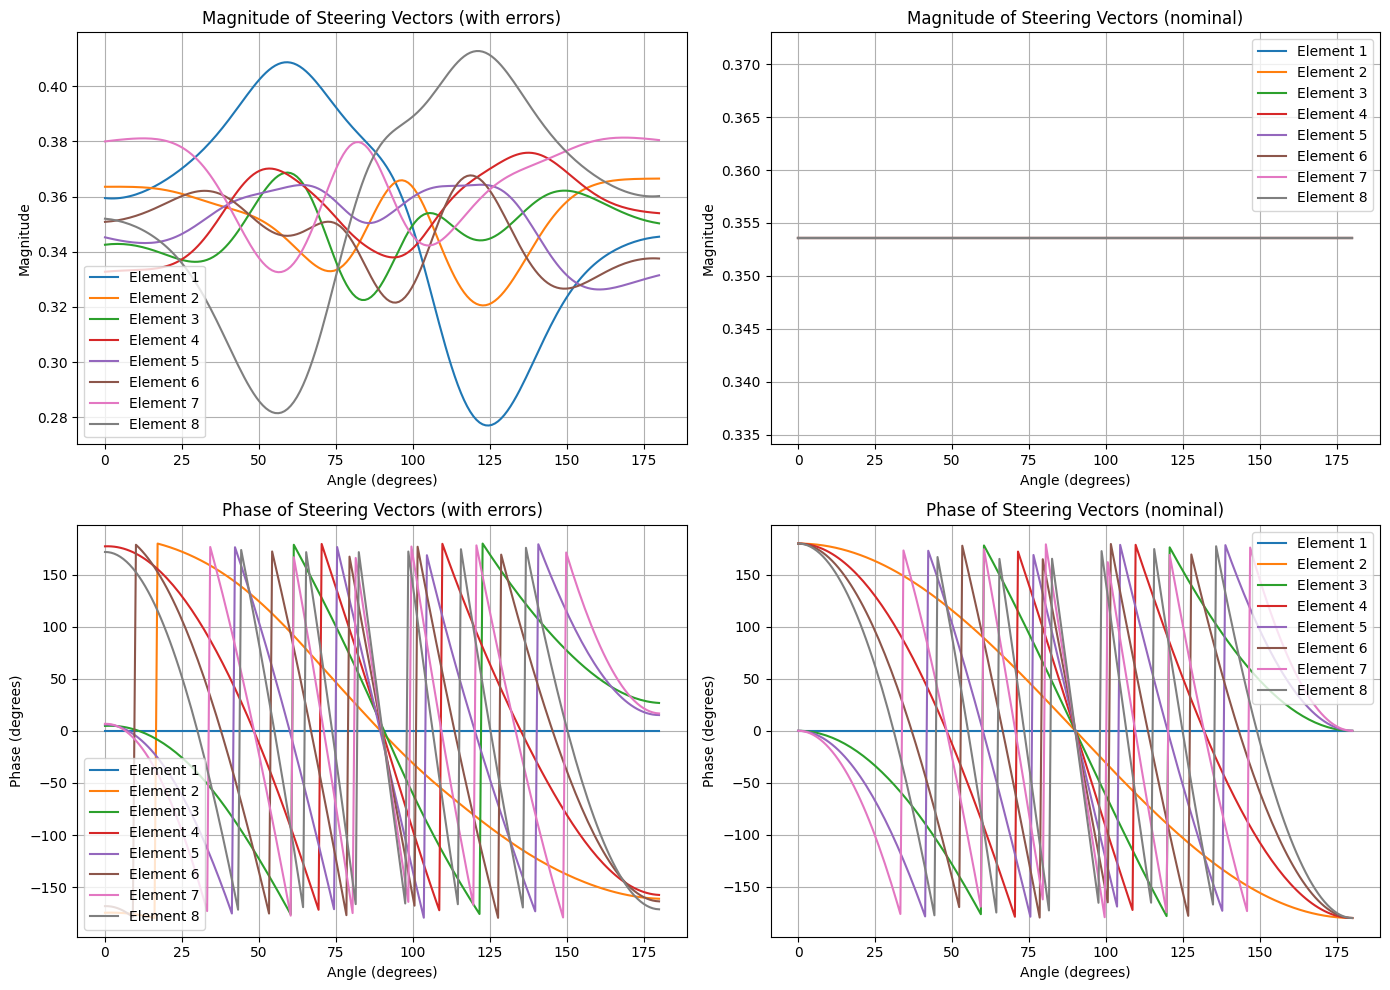

In [12]:
# Plot the steering vectors (magnitude and phase)
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# Plot magnitude of steering vectors
plt.subplot(2, 2, 1)
plt.plot(angles, np.abs(A.T))
plt.title('Magnitude of Steering Vectors (with errors)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.legend([f'Element {i+1}' for i in range(A.shape[0])])

plt.subplot(2, 2, 2)
plt.plot(angles, np.abs(A_nominal.T))
plt.title('Magnitude of Steering Vectors (nominal)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.legend([f'Element {i+1}' for i in range(A_nominal.shape[0])])

# Plot phase of steering vectors
plt.subplot(2, 2, 3)
plt.plot(angles, np.angle(A.T, deg=True))
plt.title('Phase of Steering Vectors (with errors)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Phase (degrees)')
plt.grid(True)
plt.legend([f'Element {i+1}' for i in range(A.shape[0])])

plt.subplot(2, 2, 4)
plt.plot(angles, np.angle(A_nominal.T, deg=True))
plt.title('Phase of Steering Vectors (nominal)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Phase (degrees)')
plt.grid(True)
plt.legend([f'Element {i+1}' for i in range(A_nominal.shape[0])])

plt.tight_layout()
plt.show()






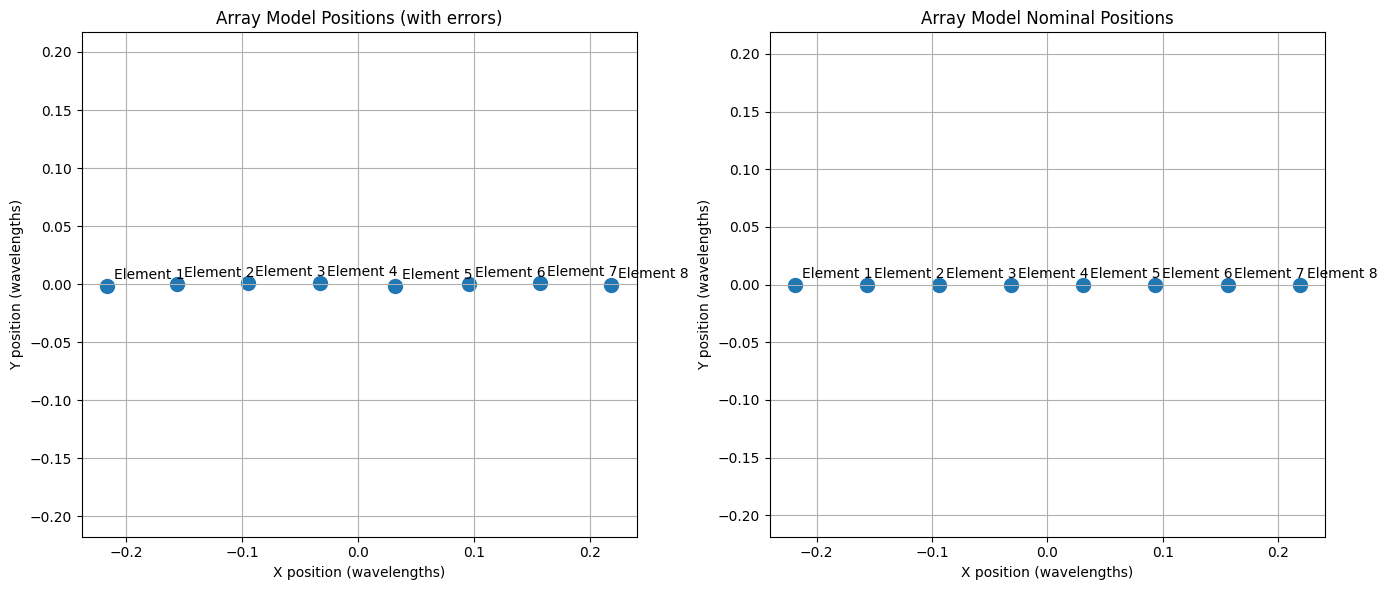

In [13]:
# Plot the positions from the array model
plt.figure(figsize=(14, 6))

# Plot actual positions from array model
plt.subplot(1, 2, 1)
plt.scatter(array_model.element_positions[:, 0], array_model.element_positions[:, 1], marker='o', s=100)
for i, (x, y) in enumerate(array_model.element_positions):
    plt.annotate(f'Element {i+1}', (x, y), xytext=(5, 5), textcoords='offset points')
plt.title('Array Model Positions (with errors)')
plt.xlabel('X position (wavelengths)')
plt.ylabel('Y position (wavelengths)')
plt.grid(True)
plt.axis('equal')

# Plot nominal positions from array model
plt.subplot(1, 2, 2)
plt.scatter(array_model.nominal_positions[:, 0], array_model.nominal_positions[:, 1], marker='o', s=100)
for i, (x, y) in enumerate(array_model.nominal_positions):
    plt.annotate(f'Element {i+1}', (x, y), xytext=(5, 5), textcoords='offset points')
plt.title('Array Model Nominal Positions')
plt.xlabel('X position (wavelengths)')
plt.ylabel('Y position (wavelengths)')
plt.grid(True)
plt.axis('equal')

plt.tight_layout()
plt.show()


In [14]:
from signalgen.array_processing import ReceivedSignal
steering_matrix = array_model.steering_matrix(signal_config.angles, nominal=False)
nominal_steering_matrix = array_model.steering_matrix(signal_config.angles, nominal=True)
x = ReceivedSignal(steering_matrix, signal, signal_config.angles, signal_config)
clean_signal = x.array_signals.copy()
noisy_object = x.add_noise(snr_db=0, source_frequencies=signal_config.frequencies, signal_bandwidth=signal_config.bandwidth, sampling_frequency=signal_config.fs)
noise = noisy_object.noise.copy()
noisy_signal = noisy_object.array_signals.copy()

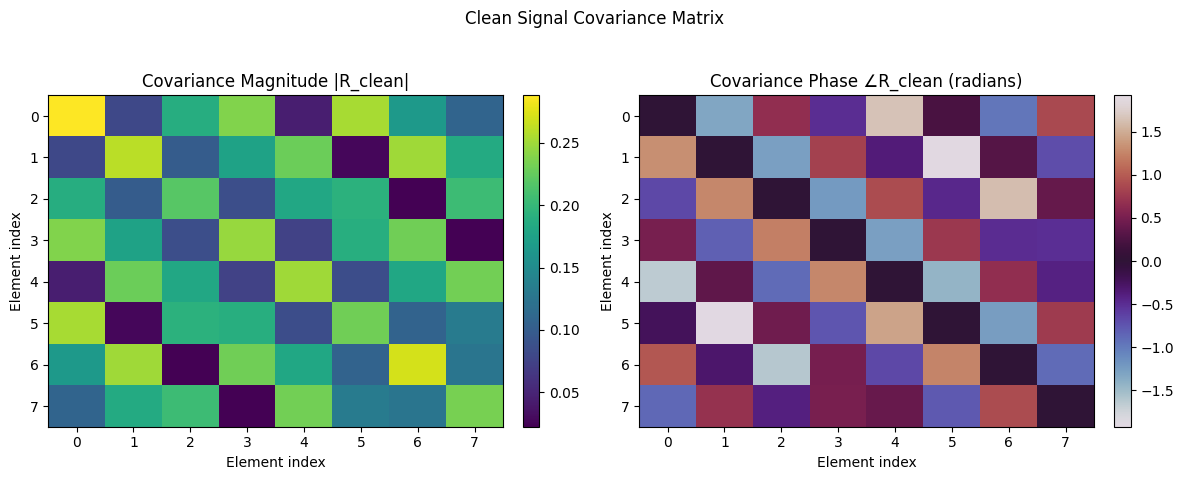

In [15]:
# Compute sample covariance matrix for the clean array signals
# clean_signal is assumed to be shape (num_elements, num_snapshots)
M, T = clean_signal.shape
R_clean = (clean_signal @ clean_signal.conj().T) / T  # M x M complex covariance

# Plot magnitude and phase of the covariance matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(np.abs(R_clean), cmap='viridis', aspect='auto')
axes[0].set_title('Covariance Magnitude |R_clean|')
axes[0].set_xlabel('Element index')
axes[0].set_ylabel('Element index')
axes[0].set_xticks(range(M))
axes[0].set_yticks(range(M))
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(np.angle(R_clean), cmap='twilight', aspect='auto')
axes[1].set_title('Covariance Phase ∠R_clean (radians)')
axes[1].set_xlabel('Element index')
axes[1].set_ylabel('Element index')
axes[1].set_xticks(range(M))
axes[1].set_yticks(range(M))
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle('Clean Signal Covariance Matrix')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

🔍 Signal Subspace Similarity Analysis
📊 Theoretical signal subspace shape: (8, 2)
📊 Sample covariance matrix shape: (8, 8)
📊 Estimated signal subspace shape: (8, 2)

🎯 Principal Angles between subspaces:
   Angle 1: 15.01°
   Angle 2: 4.53°
📏 Subspace Distance (max principal angle): 15.01°
📐 Projection Error (Frobenius norm): 0.1679
📐 Relative Projection Error: 0.1187

🔗 Individual Vector Correlations:
   Steering vector 0 ↔ Eigenvector 0: 0.9140
   Steering vector 1 ↔ Eigenvector 1: 0.2840


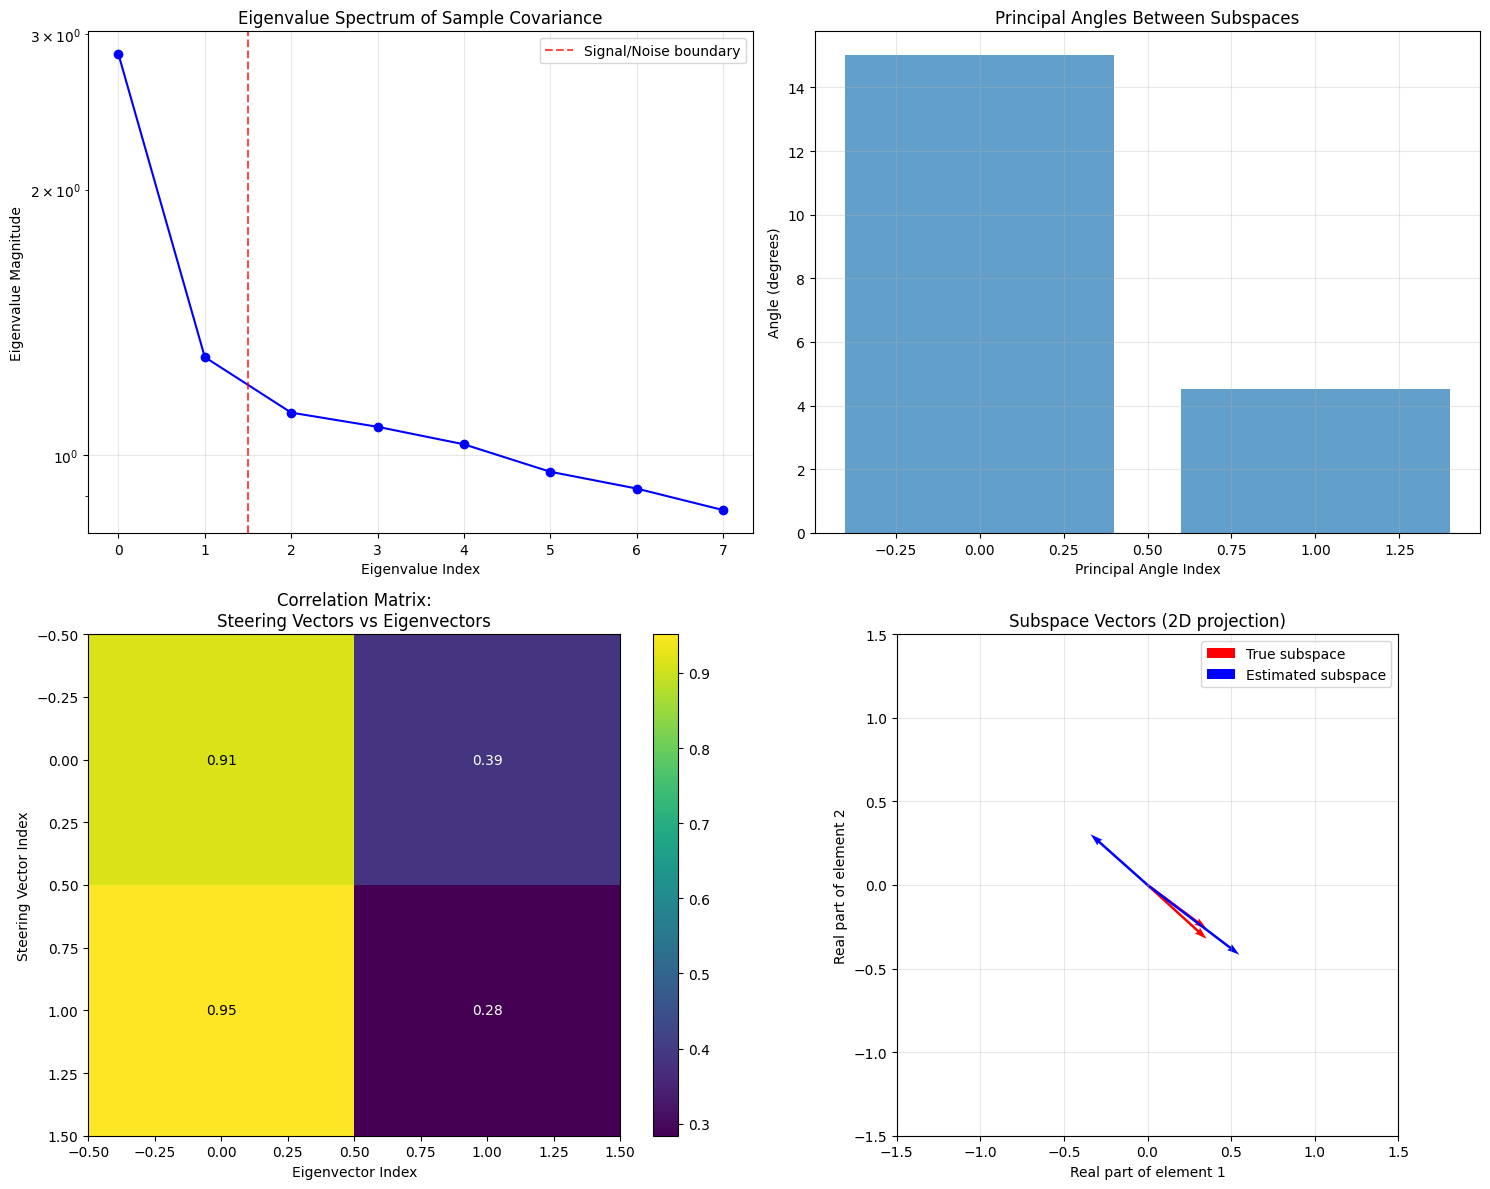


📊 SUMMARY METRICS:
   • Number of sources: 2
   • Subspace distance: 15.01°
   • Mean principal angle: 9.77°
   • Relative projection error: 0.1187
   • Mean correlation (best matches): 0.5990
   • Subspace similarity quality: Fair

✅ Subspace similarity analysis completed!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import subspace_angles
import seaborn as sns

def analyze_signal_subspace_similarity(steering_matrix, noisy_signal, signal_angles, num_sources=None):
    """
    Compare the theoretical signal subspace (steering matrix) with the estimated signal subspace 
    from noisy covariance matrix eigenvectors.
    
    Args:
        steering_matrix: Array manifold for the true signal directions
        noisy_signal: Noisy received signals (num_elements x num_snapshots)
        signal_angles: True signal angles
        num_sources: Number of sources (if None, will be estimated)
    """
    
    print("🔍 Signal Subspace Similarity Analysis")
    print("=" * 50)
    
    # 1. Theoretical signal subspace (steering matrix columns for true angles)
    if num_sources is None:
        num_sources = len(signal_angles)
    
    # Extract steering vectors for the true signal angles
    A_true = steering_matrix[:, :num_sources]  # Theoretical signal subspace
    print(f"📊 Theoretical signal subspace shape: {A_true.shape}")
    
    # 2. Estimated signal subspace from noisy covariance
    # Compute sample covariance matrix
    R_sample = np.cov(noisy_signal)
    print(f"📊 Sample covariance matrix shape: {R_sample.shape}")
    
    # Eigendecomposition of sample covariance
    eigenvals, eigenvecs = np.linalg.eigh(R_sample)
    
    # Sort in descending order
    idx = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]
    
    # Extract signal subspace (top num_sources eigenvectors)
    U_signal = eigenvecs[:, :num_sources]  # Estimated signal subspace
    print(f"📊 Estimated signal subspace shape: {U_signal.shape}")
    
    # 3. Compute subspace similarity metrics
    
    # Method 1: Principal angles between subspaces
    principal_angles_rad = subspace_angles(A_true, U_signal)
    principal_angles_deg = np.rad2deg(principal_angles_rad)
    
    print(f"\n🎯 Principal Angles between subspaces:")
    for i, angle in enumerate(principal_angles_deg):
        print(f"   Angle {i+1}: {angle:.2f}°")
    
    # Method 2: Subspace distance (largest principal angle)
    subspace_distance = np.max(principal_angles_deg)
    print(f"📏 Subspace Distance (max principal angle): {subspace_distance:.2f}°")
    
    # Method 3: Projection-based similarity
    # Project theoretical subspace onto estimated subspace
    P_estimated = U_signal @ U_signal.conj().T  # Projection matrix for estimated subspace
    projected_true = P_estimated @ A_true
    
    # Compute Frobenius norm of difference
    projection_error = np.linalg.norm(A_true - projected_true, 'fro')
    relative_projection_error = projection_error / np.linalg.norm(A_true, 'fro')
    
    print(f"📐 Projection Error (Frobenius norm): {projection_error:.4f}")
    print(f"📐 Relative Projection Error: {relative_projection_error:.4f}")
    
    # Method 4: Correlation between individual vectors
    print(f"\n🔗 Individual Vector Correlations:")
    correlations = np.zeros((num_sources, num_sources))
    
    for i in range(num_sources):
        for j in range(num_sources):
            # Compute correlation coefficient between steering vector and eigenvector
            corr = np.abs(np.vdot(A_true[:, i], U_signal[:, j])) / (
                np.linalg.norm(A_true[:, i]) * np.linalg.norm(U_signal[:, j])
            )
            correlations[i, j] = corr
    
    # Find best matching pairs
    best_matches = []
    used_eigenvecs = set()
    
    for i in range(num_sources):
        available_correlations = [(j, correlations[i, j]) for j in range(num_sources) if j not in used_eigenvecs]
        if available_correlations:
            best_j, best_corr = max(available_correlations, key=lambda x: x[1])
            best_matches.append((i, best_j, best_corr))
            used_eigenvecs.add(best_j)
            print(f"   Steering vector {i} ↔ Eigenvector {best_j}: {best_corr:.4f}")
    
    # 5. Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Eigenvalue spectrum
    axes[0, 0].semilogy(range(len(eigenvals)), eigenvals, 'bo-')
    axes[0, 0].axvline(x=num_sources-0.5, color='r', linestyle='--', alpha=0.7, label='Signal/Noise boundary')
    axes[0, 0].set_xlabel('Eigenvalue Index')
    axes[0, 0].set_ylabel('Eigenvalue Magnitude')
    axes[0, 0].set_title('Eigenvalue Spectrum of Sample Covariance')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # Plot 2: Principal angles
    axes[0, 1].bar(range(len(principal_angles_deg)), principal_angles_deg, alpha=0.7)
    axes[0, 1].set_xlabel('Principal Angle Index')
    axes[0, 1].set_ylabel('Angle (degrees)')
    axes[0, 1].set_title('Principal Angles Between Subspaces')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Correlation matrix heatmap
    im = axes[1, 0].imshow(correlations, cmap='viridis', aspect='auto')
    axes[1, 0].set_xlabel('Eigenvector Index')
    axes[1, 0].set_ylabel('Steering Vector Index')
    axes[1, 0].set_title('Correlation Matrix:\nSteering Vectors vs Eigenvectors')
    plt.colorbar(im, ax=axes[1, 0])
    
    # Add correlation values as text
    for i in range(num_sources):
        for j in range(num_sources):
            axes[1, 0].text(j, i, f'{correlations[i, j]:.2f}', 
                           ha='center', va='center', color='white' if correlations[i, j] < 0.5 else 'black')
    
    # Plot 4: Subspace comparison visualization
    # Project both subspaces to 2D for visualization (if more than 2 sources, show first 2)
    if num_sources >= 2:
        # Use first two components
        axes[1, 1].quiver(0, 0, A_true[0, 0].real, A_true[1, 0].real, 
                         angles='xy', scale_units='xy', scale=1, color='red', 
                         width=0.005, label='True subspace')
        axes[1, 1].quiver(0, 0, A_true[0, 1].real, A_true[1, 1].real, 
                         angles='xy', scale_units='xy', scale=1, color='red', width=0.005)
        
        axes[1, 1].quiver(0, 0, U_signal[0, 0].real, U_signal[1, 0].real, 
                         angles='xy', scale_units='xy', scale=1, color='blue', 
                         width=0.005, label='Estimated subspace')
        axes[1, 1].quiver(0, 0, U_signal[0, 1].real, U_signal[1, 1].real, 
                         angles='xy', scale_units='xy', scale=1, color='blue', width=0.005)
        
        axes[1, 1].set_xlim(-1.5, 1.5)
        axes[1, 1].set_ylim(-1.5, 1.5)
        axes[1, 1].set_xlabel('Real part of element 1')
        axes[1, 1].set_ylabel('Real part of element 2')
        axes[1, 1].set_title('Subspace Vectors (2D projection)')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend()
        axes[1, 1].set_aspect('equal')
    else:
        axes[1, 1].text(0.5, 0.5, 'Need ≥2 sources\nfor 2D visualization', 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Subspace Visualization (N/A)')
    
    plt.tight_layout()
    plt.show()
    
    # 6. Summary metrics
    print(f"\n📊 SUMMARY METRICS:")
    print(f"   • Number of sources: {num_sources}")
    print(f"   • Subspace distance: {subspace_distance:.2f}°")
    print(f"   • Mean principal angle: {np.mean(principal_angles_deg):.2f}°")
    print(f"   • Relative projection error: {relative_projection_error:.4f}")
    print(f"   • Mean correlation (best matches): {np.mean([match[2] for match in best_matches]):.4f}")
    
    # Quality assessment
    if subspace_distance < 5:
        quality = "Excellent"
    elif subspace_distance < 15:
        quality = "Good"
    elif subspace_distance < 30:
        quality = "Fair"
    else:
        quality = "Poor"
    
    print(f"   • Subspace similarity quality: {quality}")
    
    return {
        'principal_angles_deg': principal_angles_deg,
        'subspace_distance': subspace_distance,
        'projection_error': projection_error,
        'relative_projection_error': relative_projection_error,
        'correlations': correlations,
        'best_matches': best_matches,
        'eigenvalues': eigenvals,
        'estimated_subspace': U_signal,
        'theoretical_subspace': A_true
    }

# Run the analysis
results = analyze_signal_subspace_similarity(
    nominal_steering_matrix, 
    noisy_signal, 
    signal_config.angles,  # Assuming this contains the true angles
    num_sources=signal_config.num_sources
)

print("\n✅ Subspace similarity analysis completed!")

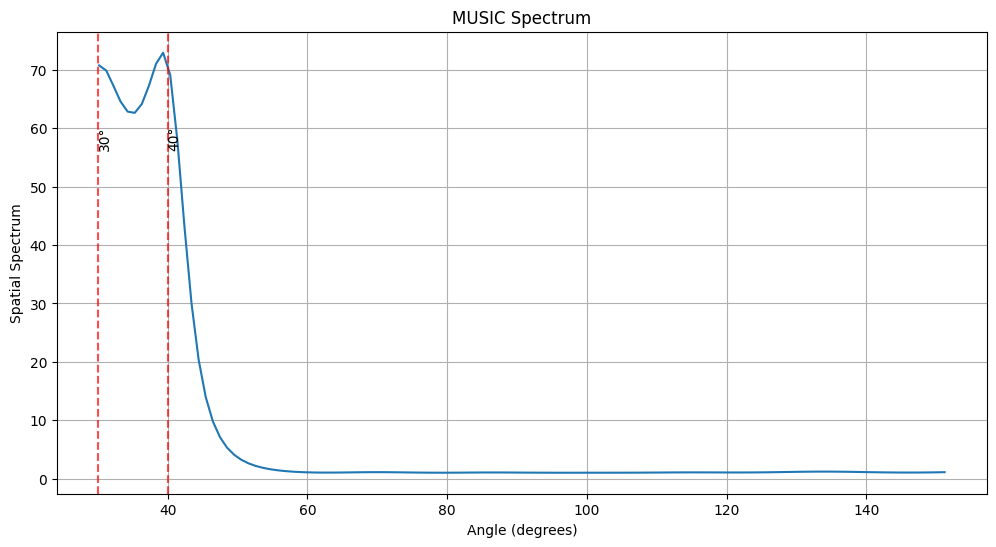

In [7]:
num_sources = signal_config.num_sources
full_angles = np.linspace(30.2, 151.2, 120)
array_manifold = array_model.steering_matrix(full_angles, nominal=True)
R_sample = np.cov(noisy_signal)
# Eigendecomposition of sample covariance
eigenvals, eigenvecs = np.linalg.eigh(R_sample)

# Sort in descending order
idx = eigenvals.argsort()[::-1]
eigenvals = eigenvals[idx]
eigenvecs = eigenvecs[:, idx]

# Extract signal subspace (top num_sources eigenvectors)
U_noise = eigenvecs[:, num_sources:]  # Estimated signal subspace
# print(f"📊 Estimated noise subspace shape: {U_noise.shape}")
E_n = U_noise @ U_noise.conj().T
denominator = np.real(np.diag(array_manifold.conj().T @ E_n @ array_manifold))
music_spectrum = 1.0 / denominator
# Find the peaks in the MUSIC spectrum
peak_indices = np.argsort(music_spectrum)[-10:]
peak_angles = full_angles[peak_indices]
peak_values = music_spectrum[peak_indices]
# print(f'MUSIC peaks at angles: {peak_angles} degrees, values: {peak_values}')
# Plot MUSIC spectrum vs angles
plt.figure(figsize=(12, 6))
plt.plot(full_angles, music_spectrum)
plt.title('MUSIC Spectrum')
plt.xlabel('Angle (degrees)')
plt.ylabel('Spatial Spectrum')
plt.grid(True)

# Mark the true angles if available
if hasattr(signal_config, 'angles'):
    for angle in signal_config.angles:
        plt.axvline(x=angle, color='r', linestyle='--', alpha=0.7)
        plt.text(angle, 0.8*np.max(music_spectrum), f"{angle}°", 
                 rotation=90, verticalalignment='center')

plt.show()

# SNR Verification Test

Let's verify that the SNR implementation in the dataset generation is correct by:
1. Checking the actual signal power
2. Checking the actual noise power  
3. Computing the actual SNR from the noisy signal
4. Comparing with the specified SNR value

Testing SNR implementation...

🔬 SNR VERIFICATION TEST
Target SNR: 10 dB

📊 Trial 1 Details:
   Signal power: 0.254473
   Noise power: 0.099872
   SNR (linear): 2.547992
   SNR (dB): 4.06 dB
   Target SNR: 10 dB
   Error: -5.94 dB

📈 Statistics over 50 trials:
   Mean actual SNR: 3.93 ± 0.09 dB
   Target SNR: 10 dB
   Mean error: -6.07 dB
   Error range: [-6.31, -5.92] dB

❌ FAIL - SNR implementation quality: Poor


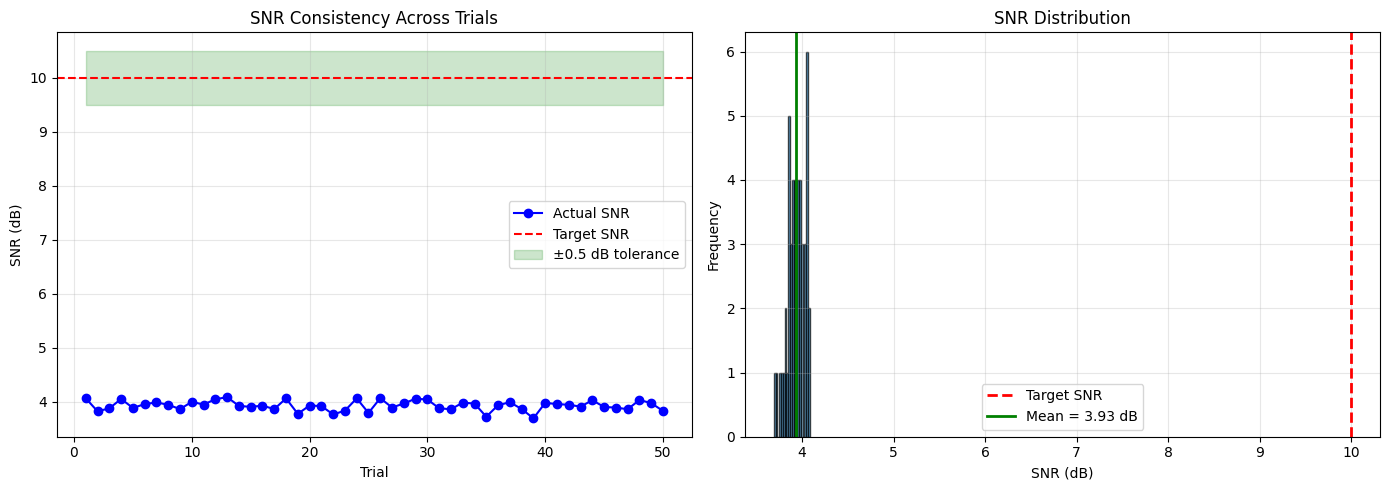



🔬 SNR VERIFICATION TEST
Target SNR: 0 dB

📊 Trial 1 Details:
   Signal power: 0.250916
   Noise power: 1.015608
   SNR (linear): 0.247060
   SNR (dB): -6.07 dB
   Target SNR: 0 dB
   Error: -6.07 dB

📈 Statistics over 50 trials:
   Mean actual SNR: -6.07 ± 0.09 dB
   Target SNR: 0 dB
   Mean error: -6.07 dB
   Error range: [-6.27, -5.84] dB

❌ FAIL - SNR implementation quality: Poor


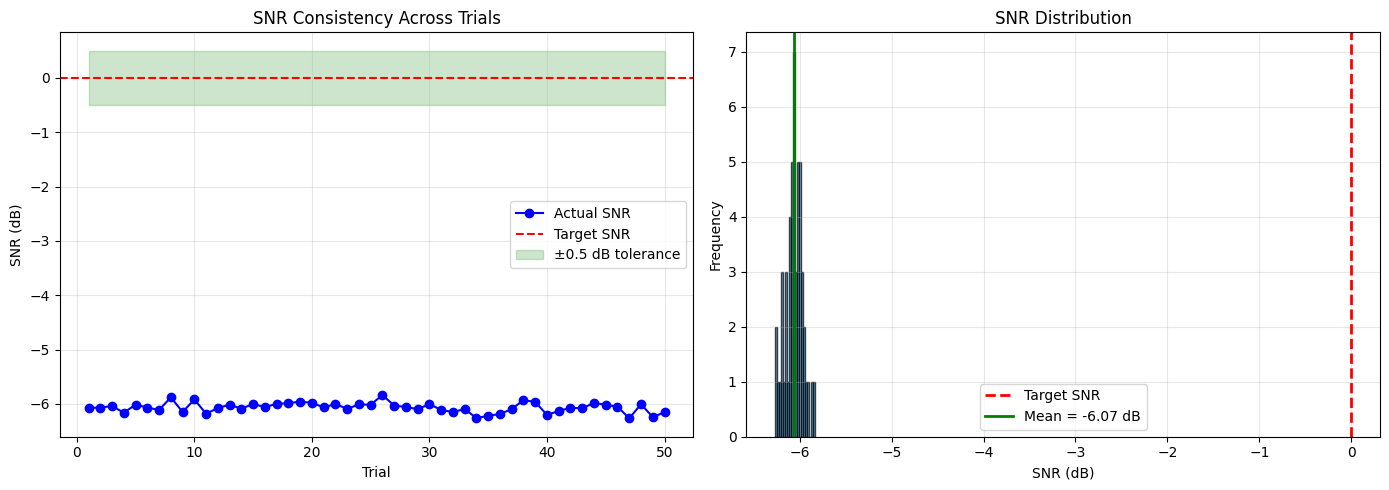



🔬 SNR VERIFICATION TEST
Target SNR: -10 dB

📊 Trial 1 Details:
   Signal power: 0.245689
   Noise power: 10.106308
   SNR (linear): 0.024310
   SNR (dB): -16.14 dB
   Target SNR: -10 dB
   Error: -6.14 dB

📈 Statistics over 50 trials:
   Mean actual SNR: -16.09 ± 0.08 dB
   Target SNR: -10 dB
   Mean error: -6.09 dB
   Error range: [-6.27, -5.88] dB

❌ FAIL - SNR implementation quality: Poor


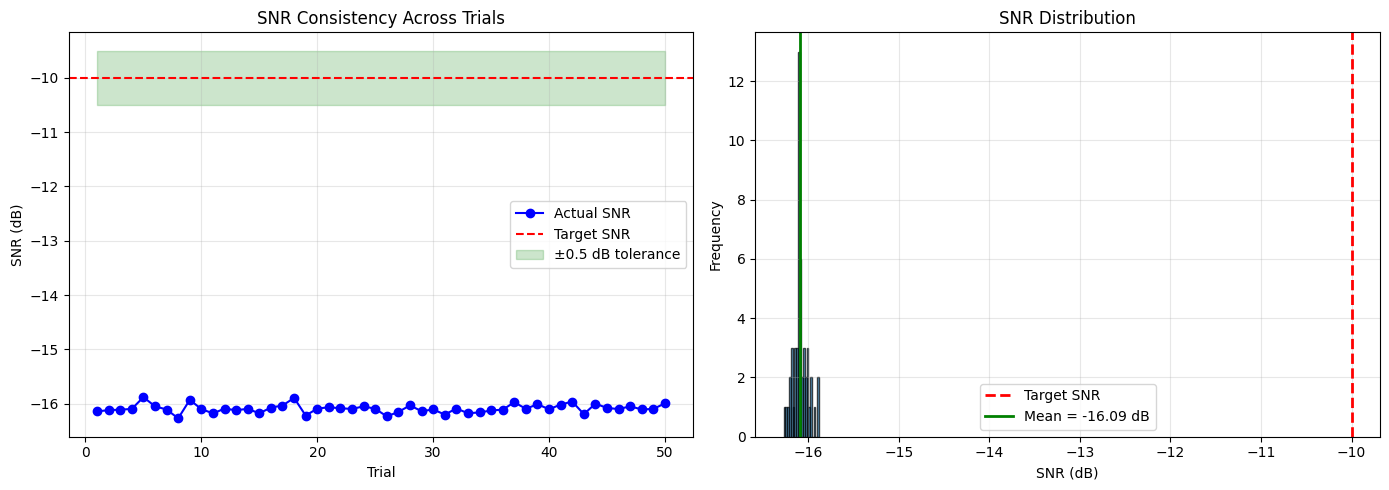

In [8]:
def verify_snr_implementation(snr_db_target=10, num_trials=10):
    """
    Verify that the SNR implementation correctly produces the specified SNR.
    
    Tests:
    1. Signal power calculation
    2. Noise power calculation
    3. Actual SNR from noisy signal
    4. Comparison with target SNR
    """
    print(f"🔬 SNR VERIFICATION TEST")
    print(f"Target SNR: {snr_db_target} dB")
    print("=" * 60)
    
    actual_snrs = []
    signal_powers = []
    noise_powers = []
    
    for trial in range(num_trials):
        # Generate clean signal
        signal_generator = SignalGenerator(signal_config)
        t, signals = signal_generator.generate_signals()
        
        # Create received signal
        steering_matrix = array_model.steering_matrix(signal_config.angles, nominal=True)
        received = ReceivedSignal(steering_matrix, signals, signal_config.angles, signal_config)
        
        # Get clean signal power
        clean_signal = received.array_signals.copy()
        signal_power = np.mean(np.abs(clean_signal) ** 2)
        
        # Add noise
        noisy_received = received.add_noise(
            snr_db=snr_db_target,
            source_frequencies=signal_config.frequencies,
            signal_bandwidth=signal_config.bandwidth,
            sampling_frequency=signal_config.fs,
            frequency_selective=True
        )
        
        # Get noise power
        noise = noisy_received.noise
        noise_power = np.mean(np.abs(noise) ** 2)
        
        # Calculate actual SNR
        actual_snr_linear = signal_power / noise_power
        actual_snr_db = 10 * np.log10(actual_snr_linear)
        
        actual_snrs.append(actual_snr_db)
        signal_powers.append(signal_power)
        noise_powers.append(noise_power)
        
        if trial == 0:
            print(f"\n📊 Trial {trial + 1} Details:")
            print(f"   Signal power: {signal_power:.6f}")
            print(f"   Noise power: {noise_power:.6f}")
            print(f"   SNR (linear): {actual_snr_linear:.6f}")
            print(f"   SNR (dB): {actual_snr_db:.2f} dB")
            print(f"   Target SNR: {snr_db_target} dB")
            print(f"   Error: {actual_snr_db - snr_db_target:.2f} dB")
    
    # Statistics across trials
    mean_snr = np.mean(actual_snrs)
    std_snr = np.std(actual_snrs)
    mean_error = mean_snr - snr_db_target
    
    print(f"\n📈 Statistics over {num_trials} trials:")
    print(f"   Mean actual SNR: {mean_snr:.2f} ± {std_snr:.2f} dB")
    print(f"   Target SNR: {snr_db_target} dB")
    print(f"   Mean error: {mean_error:.2f} dB")
    print(f"   Error range: [{np.min(actual_snrs) - snr_db_target:.2f}, {np.max(actual_snrs) - snr_db_target:.2f}] dB")
    
    # Assessment
    if abs(mean_error) < 0.5 and std_snr < 1.0:
        status = "✅ PASS"
        quality = "Excellent"
    elif abs(mean_error) < 1.0 and std_snr < 2.0:
        status = "✅ PASS"
        quality = "Good"
    elif abs(mean_error) < 2.0:
        status = "⚠️  WARNING"
        quality = "Acceptable"
    else:
        status = "❌ FAIL"
        quality = "Poor"
    
    print(f"\n{status} - SNR implementation quality: {quality}")
    
    # Visualization
    plt.figure(figsize=(14, 5))
    
    # Plot 1: SNR across trials
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_trials + 1), actual_snrs, 'bo-', label='Actual SNR')
    plt.axhline(y=snr_db_target, color='r', linestyle='--', label='Target SNR')
    plt.fill_between(range(1, num_trials + 1), 
                     snr_db_target - 0.5, snr_db_target + 0.5,
                     alpha=0.2, color='g', label='±0.5 dB tolerance')
    plt.xlabel('Trial')
    plt.ylabel('SNR (dB)')
    plt.title('SNR Consistency Across Trials')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot 2: Distribution
    plt.subplot(1, 2, 2)
    plt.hist(actual_snrs, bins=20, edgecolor='black', alpha=0.7)
    plt.axvline(x=snr_db_target, color='r', linestyle='--', linewidth=2, label='Target SNR')
    plt.axvline(x=mean_snr, color='g', linestyle='-', linewidth=2, label=f'Mean = {mean_snr:.2f} dB')
    plt.xlabel('SNR (dB)')
    plt.ylabel('Frequency')
    plt.title('SNR Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'mean_snr': mean_snr,
        'std_snr': std_snr,
        'mean_error': mean_error,
        'actual_snrs': actual_snrs,
        'target_snr': snr_db_target
    }

# Test with different SNR values
print("Testing SNR implementation...\n")
results_10db = verify_snr_implementation(snr_db_target=10, num_trials=50)
print("\n" + "="*60 + "\n")
results_0db = verify_snr_implementation(snr_db_target=0, num_trials=50)
print("\n" + "="*60 + "\n")
results_minus10db = verify_snr_implementation(snr_db_target=-10, num_trials=50)

# ⚠️ Potential SNR Implementation Issues Found

## Issue 1: Reference Power Calculation
**Line 486 in array_processing.py:**
```python
signal_power = np.mean(np.abs(self.source_signals[0, :]) ** 2)
```

This calculates signal power from **source_signals[0, :]** (the SOURCE signal before steering matrix multiplication), but the noise is added to **array_signals** (AFTER steering matrix multiplication).

**Problem:** The array_signals power depends on:
- Steering matrix normalization (1/√M factor)
- Array geometry
- Number of elements M

**Correct approach:** Should use:
```python
signal_power = np.mean(np.abs(self.array_signals) ** 2)
```

## Issue 2: Frequency-Selective Noise Scaling
**Line 490:**
```python
noise_power = (signal_power / (10 ** (snr_db / 10))) * (sampling_frequency / signal_bandwidth)
```

The `(fs / bandwidth)` scaling is applied when using frequency-selective noise, but this might not be correct because:
- Filtering in frequency domain already limits noise to bandwidth
- This scaling might **over-boost** the noise power

## Issue 3: Full Bandwidth Mode (Line 497)
```python
noise = np.fft.ifft(noise_freq, axis=1) * np.sqrt(T)
```

The `* np.sqrt(T)` scaling after IFFT seems incorrect - IFFT already handles scaling properly.

---

Let me verify these issues with the test below...